In [21]:
import stock_data
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
# def simulate_portfolio(prices, signals, initial_balance=10000):
#     """
#     Simulates portfolio balance over time based on buy/sell signals.

#     Parameters:
#         prices (pd.Series): Series of actual prices (e.g., closing price).
#         signals (list or Series): List of 'buy' or 'sell' signals (must align with prices).
#         initial_balance (float): Starting portfolio value.

#     Returns:
#         pd.DataFrame: Portfolio balance, holdings, and action log over time.
#     """
#     df = pd.DataFrame({
#         "price": prices.values,
#         "signal": signals
#     }).reset_index(drop=True)

#     balance = initial_balance
#     holdings = 0
#     portfolio_values = []

#     for i in range(len(df) - 1):  # use next day's price
#         today_signal = df.loc[i, "signal"]
#         next_price = df.loc[i + 1, "price"]

#         if today_signal == "buy" and holdings == 0:
#             # Buy with full balance
#             holdings = balance / next_price
#             assert(not np.isnan(holdings))
#             balance = 0
#             action = "BUY"
#         elif today_signal == "sell" and holdings > 0:
#             # Sell all holdings
#             balance = holdings * next_price
#             holdings = 0
#             action = "SELL"
#         else:
#             action = "HOLD"

#         portfolio_value = balance + holdings * next_price
#         portfolio_values.append({
#             "day": i,
#             "price": next_price,
#             "signal": today_signal,
#             "action": action,
#             "holdings": holdings,
#             "balance": balance,
#             "portfolio_value": portfolio_value
#         })

#     return pd.DataFrame(portfolio_values)

def compute_sharpe_ratio(portfolio_df, risk_free_rate=0.0, period_per_year=52):
    """
    Compute annualized Sharpe Ratio from a portfolio value series.

    Parameters:
        portfolio_df: DataFrame with 'portfolio_value' column
        risk_free_rate: annual risk-free rate (default 0)
        period_per_year: number of periods per year (e.g., 52 for weekly)

    Returns:
        Sharpe ratio (float)
    """
    # Compute periodic returns (e.g., weekly)
    returns = portfolio_df["portfolio_value"].pct_change().dropna()

    # Mean and std of returns
    mean_return = returns.mean()
    std_return = returns.std()

    # Annualize
    excess_return = mean_return - (risk_free_rate / period_per_year)
    sharpe_ratio = (excess_return / std_return) * np.sqrt(period_per_year)

    return sharpe_ratio

In [23]:
tickers = [
    # The classics
    "SPY", "QQQ",

    # Blue-chip stocks
    "JNJ", "PG", "KO", "PEP", "WMT", "MCD",
    
    # Low-volatility ETFs
    "USMV", "SPLV", "VIG", "SCHD", "VTV",
    
    # Defensive sector ETFs
    "XLU", "XLV", "XLP",

    "DGRW", "VYM", "HDV", "NOBL", "DGRO", "FDL", "DVY", "SPHD", "VPU", "FSTA", "FUTY", "IDU", "RHS", "VDC", "IYK", "PFXF", "PFFD", "PSK", "LDRS", "LVHD", "QDF", "FTSD", "SPLB", "SPBO", "BND", "AGG", "SHY", "TIP"
]


df = pd.DataFrame()
for ticker in tickers:
    sub_df = stock_data.get_normalized_data(ticker)
    sub_df["ticker"] = ticker
    df = pd.concat([df, sub_df], axis=0)

In [24]:
# Set target
# df["Target"] = df['price'].shift(-1) # regression
df = df.dropna()
df['Target'] = (df['price'].shift(-1) > df['price']).astype(int) # classification

In [25]:
X = df.copy()
X = X.drop(labels=["Target", "ticker"], axis=1)
X["date"] = pd.to_datetime(X["date"]).astype('int64')

y = df["Target"].copy()

split_index = int(len(df) * 0.8)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [26]:
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))
# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error

# Scale features (PyTorch models need this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Define neural network model
# class BinaryClassifier(nn.Module):
#     def __init__(self, input_dim):
#         super(BinaryClassifier, self).__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 64),
#             nn.ReLU(),
#             # nn.Dropout(0.3),
#             nn.Linear(64, 128),
#             nn.ReLU(),
#             nn.Linear(128, 128),
#             nn.ReLU(),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Linear(64, 64),
#             nn.ReLU(),
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(32, 1),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         return self.net(x)

class BinaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.Mish(),
            nn.Dropout(0.2),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.Mish(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.Mish(),
            
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.Mish(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.Mish(),
            nn.Dropout(0.2),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
model = BinaryClassifier(input_dim=X_train_tensor.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Train loop
epochs = int(100)
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    y_prob = torch.sigmoid(model(X_test_tensor).squeeze())
    y_pred = (y_prob >= 0.5).int()

# Convert to NumPy for evaluation
y_prob_np = y_prob.numpy()
y_pred_np = y_pred.numpy()
y_test_np = y_test_tensor.squeeze().numpy()

# Metrics
print("Accuracy:", accuracy_score(y_test_np, y_pred_np))
print("\nClassification Report:\n", classification_report(y_test_np, y_pred_np))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_np, y_pred_np))

Epoch [5/100] Loss: 0.6959
Epoch [10/100] Loss: 0.6930
Epoch [15/100] Loss: 0.6915


In [ ]:
# SIM_TICKER = "SPY"

# sim_X = stock_data.get_normalized_data(SIM_TICKER)
# sim_prices = stock_data.get_stock_data(SIM_TICKER)["price"].iloc[sim_X.index]
# sim_X["date"] = pd.to_datetime(sim_X["date"]).astype('int64')

# For RandomForest:
# signals = classify_signal_with_hold(???, 0.95)
# For NN:
# sim_X_tensor = torch.tensor(scaler.transform(sim_X), dtype=torch.float32)
# model.eval()
# with torch.no_grad():
#     y_prob = torch.sigmoid(model(sim_X_tensor).squeeze())
#     y_pred = (y_prob >= 0.5).int().numpy()
#     y_prob = y_prob.numpy()
# probabilities.loc[probabilities["prob"] > 0.5,"class"] = "buy"
# probabilities.loc[probabilities["prob"] < 0.2,"class"] = "sell"
# display(probabilities[probabilities["class"] == "buy"])
# signals = probabilities["class"]
# portfolio_df = simulate_portfolio(prices=sim_prices, signals=signals)
# portfolio_df[portfolio_df["action"] != "HOLD"]

In [ ]:
class PortfolioSimulator:
    def __init__(self, assets, cash=10000):
        self.cash = cash
        self.positions = {asset: 0 for asset in assets}
        self.asset_prices = {asset: 1 for asset in assets}  # placeholder, update each step

    def update_prices(self, new_prices):
        self.asset_prices = new_prices

    def act(self, model_outputs, threshold=0.2):
        """
        model_outputs: dict of {asset: confidence}
        confidence is a float between 0 and 1
        threshold defines a no-action zone around 0.5
        """
        for asset, conf in model_outputs.items():
            price = self.asset_prices[asset]
            if np.isnan(price) or np.isnan(model_outputs[asset]):
                continue

            deviation = conf - 0.5

            if abs(deviation) < threshold:
                continue  # HOLD

            # Scale action size by confidence deviation
            action_strength = abs(deviation) * 2  # scale 0..1

            if deviation > 0:
                # BUY
                amount_to_spend = self.cash * action_strength * 0.1  # 10% cap
                quantity = amount_to_spend / price
                self.cash -= quantity * price
                self.positions[asset] += quantity
            else:
                # SELL
                quantity = self.positions[asset] * action_strength
                self.cash += quantity * price
                self.positions[asset] -= quantity

    def value(self):
        return self.cash + sum(
            self.positions[asset] * self.asset_prices[asset]
            for asset in self.positions if not np.isnan(self.asset_prices[asset])
        )


In [ ]:
# testing
assets = ["SPY", "QQQ", "VDC", "XLU", "XLV", "XLP", "QDF", "PSK"]

portfolio = PortfolioSimulator(assets=assets)
portfolio_value = []

df_prices = pd.concat([
    stock_data.get_stock_data(symbol).set_index('date').rename(columns={'price': symbol})
    for symbol in assets
], axis=1).reset_index(drop=True)

df_probabilities = {}
model.eval()
with torch.no_grad():
    for asset in assets:
        sim_X = stock_data.get_normalized_data(asset)
        sim_X["date"] = pd.to_datetime(sim_X["date"]).astype("int64")
        sim_tensor = torch.tensor(scaler.transform(sim_X), dtype=torch.float32)
        probs = torch.sigmoid(model(sim_tensor).squeeze()).numpy()
        assert(len(sim_X) == len(probs))
        
        df_probabilities[asset] = probs
df_probabilities = pd.DataFrame(df_probabilities)
df_probabilities

for i in range(1324): # make into constant
    prices_this_week = df_prices.iloc[i]
    probs_this_week  = df_probabilities.iloc[i]
    portfolio.update_prices(prices_this_week)
    portfolio.act(probs_this_week)
    portfolio_value.append(portfolio.value())

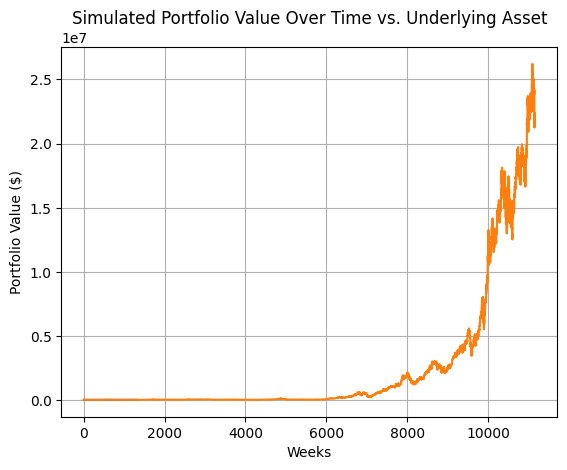

Final Portfolio Value: $11401.98


In [ ]:
import matplotlib.pyplot as plt
plt.plot(portfolio_value)
# def plot_buy_and_hold(ticker):
#     sim_prices = stock_data.get_stock_data(ticker)["price"]
#     plt.plot((sim_prices/sim_prices[0]) * portfolio_value[0])

plot_buy_and_hold("SPY")
# plot_buy_and_hold("QQQ")

plt.plot(())
plt.title("Simulated Portfolio Value Over Time vs. Underlying Asset")
plt.xlabel("Weeks")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)
plt.show()

# Optional: print final value
print(f"Final Portfolio Value: ${portfolio_value[-1]:.2f}")
